In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

from scripts import lesion_diagnostics
import os
from pathlib import Path
import pandas as pd
import numpy as np
import nibabel as nib
import json
import pickle as pkl
from collections import defaultdict

import scripts.compile_run_metrics
import helpers.utils
import scripts.inference
from IPython.display import clear_output

from reload_recursive import reload_recursive
from tqdm.notebook import tqdm


In [2]:
reload_recursive(scripts.compile_run_metrics)

reload_recursive(scripts.inference)
from scripts.inference import uncrop_predictions

reload_recursive(helpers.utils)
from helpers.utils import dice_score

import helpers.shell_interface
reload_recursive(helpers.shell_interface)
from helpers.shell_interface import open_itksnap_workspace_cmd

import core.dataset
reload_recursive(core.dataset)
from core.dataset import Dataset

import core.experiment
reload_recursive(core.experiment)
from core.experiment import Experiment

from scripts import lesion_diagnostics as lesion_dx
from scripts.compile_run_metrics import load_or_cache_run

from analysis.image import lesion_analysis
import analysis.image
reload_recursive(analysis.image)
from analysis.image import plotting 

import numpy as np
from scipy.spatial import ConvexHull
from scipy import ndimage
import nibabel as nib

from scipy import ndimage
import matplotlib.colors as mcolors

In [ ]:
# load cases

dataset_name = "roi_train2"
dataset = Dataset(dataset_name)
experiment_name = "stage6_sweep_dicece_wts/run1"
experiment = Experiment.from_run_dir(dataset.work_home/experiment_name)
suffix = f"xy{experiment.preprocess_config.expand_xy}_z{experiment.preprocess_config.expand_z}"

### Good Confluent Lesion Case

subid 1293, lesion 1.

This is a good example of a subject with a large confluent lesion complex where two separate rims were inferred for the same lesion.
The groundtruth PRL label does not have two rims, but there are other cases where this happens, so examining the inference here is demonstrative. We should consider both rims.

#### Identifying the rim units

A single rim unit may not always be internally connected. I can use binary_closing make sure each distinct rim becomes one unit that gets connected by ndimage.label. Then I can sort the connected components by size and get largest ones.
- How should I decide how many rims to consider from the top? I imagine there will be one or two (max 3) non-trivial units, and the remaining components would be a few voxels in size. 
- What is a smart way to automatically grab the non trivial rim units?

#### Producing the rim units

Backing up a step: with ndimage.binary_closing, I can control the number of iterations and the structure used to dilate and erode. If I wanted to preserve the "shell-y" nature of the rims rather than turning them into blobs, is there a principled way to do this? 
- If the iterations are too low, I may not end up combining the the unit, and it'd get missed by connected components; too high and it becomes a blob

I could either pick a number of iterations and a structure and go with that, or I could do a two stage process where I
1. Do binary_closing aggressively to identify the connected component units
2. Do a more careful binary_closing and assign voxels to connected component units based on the results of 1

I think I like the two stage approach. I can return the more conservative closure along with the largest connected components of the aggressive one, and then I'll have all I need to analyze each rim unit by itself

My biggest question now is just about ndimage.generate_binary_structure(3,1) vs ndimage.generate_binary_structure(3,2)

### What prompted this?

I now have T2 lesion probability maps. I want to use that to derive features related to rims, and so it becomes important to have definitive rim units

925
110


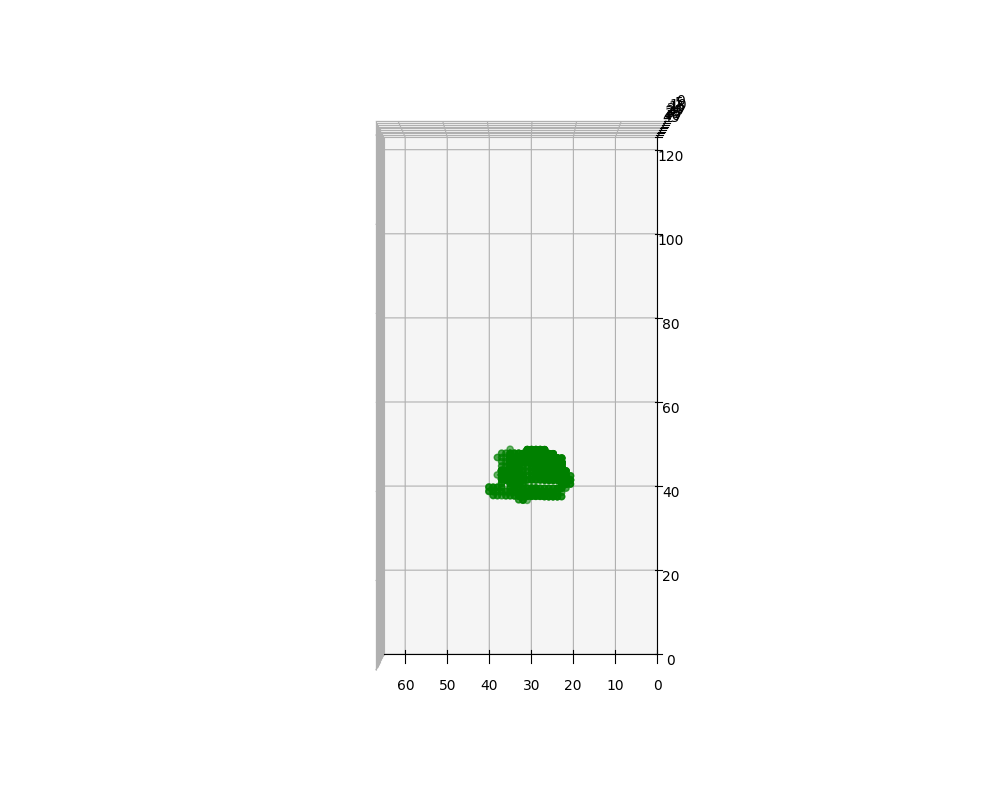

In [ ]:
full_data = lesion_analysis.analyze_prl_case(experiment.cases.loc[(1293, 1)], dataset)

# picking up where get_lesion_rim leaves off in analyze_prl_case
# I checked, and visually, two rim complexes are apparent. 
rim = full_data[1]['rim_infer']


concomp_s = ndimage.generate_binary_structure(3,3)
rim_close1 = ndimage.binary_closing(rim, iterations=2, structure=concomp_s)
labeled, n_components = ndimage.label(rim_close1, structure=concomp_s)
sorted_comps = sorted(range(1, n_components+1), key=lambda comp_id: np.sum(labeled==comp_id), reverse=True)

# just do simple thresholding for now
components = [comp_i for comp_i in sorted_comps if np.sum(labeled==comp_i) > 10]
for comp_i in components:
    print(f"Component {comp_i} size: ", np.sum(labeled==comp_i), " voxels")
labeled[~np.isin(labeled, components)] = 0
    
# Now do a more careful closure
#? What would using generate_binary_structure(3,1) change practically? Is there an 
#?   obviously better choice if I want a 3D shell-like shape?
concomp_s = ndimage.generate_binary_structure(3,1)
rim_close2 = ndimage.binary_closing(rim, iterations=2, structure=concomp_s)


comp_i = 0
comp_mask = labeled==sorted_comps[comp_i]

z_slice = None
if z_slice:
    comp_mask_to_plot = comp_mask[:,:,z_slice]
else:
    comp_mask_to_plot = comp_mask


coords = np.argwhere(comp_mask_to_plot).T
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(*coords, c="green")
ax.set_xlim([0, rim.shape[0]])
ax.set_ylim([0, rim.shape[1]])
ax.set_zlim([0, rim.shape[2]])

ax.set_aspect('equal')
ax.view_init(elev=-90, roll=90, azim=0)

In [ ]:
rim_close2*labeled

array([0, 1, 2], dtype=int32)